In [1]:
import pandas as pd

DIR_DATA = "./dataset/.ignore"

feature_cols = [
   "RELEVANCE_FEAT", "total_words", "total_sentences", 
   "avg_sentence_len", "unique_word_ratio", "pos_word_ratio", "SPELLING_FEAT"
]

In [2]:
from keras.models import load_model
import pickle

scaler_path = "./pickle/scaler.pkl"
print(f"Loading scaler from {scaler_path}...")
with (open(scaler_path, "rb")) as f:
   scaler = pickle.load(f)
print("Scaler loaded")

df_test = pd.read_csv("{}/df_test_final.csv".format(DIR_DATA))
print(f"Total test data: {len(df_test)}")

X_test = df_test[feature_cols].values
y_test = df_test['LABEL'].values

X_test_scaled = scaler.transform(X_test)

model = load_model("./models/aes_model.keras")

print("Predicting test data...")
y_pred_prob_test = model.predict(X_test_scaled)
y_pred_class_test = (y_pred_prob_test > 0.5).astype(int)
print("Predict completed!")

/Users/rivaalms/Developer/widyatama/aes2/aes/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loading scaler from ./pickle/scaler.pkl...
Scaler loaded
Total test data: 1829
Predicting test data...
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step
Predict completed!


In [3]:
from sklearn.metrics import classification_report, f1_score

print("\n=== FINAL RESULTS ===")
print(classification_report(y_test, y_pred_class_test))

final_f1 = f1_score(y_test, y_pred_class_test)
print(f"Final score: {final_f1:.4f}")


=== FINAL RESULTS ===
              precision    recall  f1-score   support

           0       0.56      0.37      0.45       682
           1       0.69      0.83      0.75      1147

    accuracy                           0.66      1829
   macro avg       0.62      0.60      0.60      1829
weighted avg       0.64      0.66      0.64      1829

Final score: 0.7517


In [4]:
df_test['pred_class'] = y_pred_class_test.flatten()
df_incorrect_test = df_test[df_test['LABEL'] != df_test['pred_class']]

print(f"Total test data: {len(df_test)}")
print(f"Total incorrect test data: {len(df_incorrect_test)} ({len(df_incorrect_test)/len(df_test)*100:.2f}%)")

fp_test = df_incorrect_test[df_incorrect_test['pred_class'] == 1]
print(f"Total false positives: {len(fp_test)}")

fn_test = df_incorrect_test[df_incorrect_test['pred_class'] == 0]
print(f"Total false negatives: {len(fn_test)}")

Total test data: 1829
Total incorrect test data: 627 (34.28%)
Total false positives: 429
Total false negatives: 198


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

df_viz = df_test.copy()

df_viz["actual"] = y_test
df_viz["predicted"] = y_pred_class_test

def get_category(row):
   if row["actual"] == 1 and row["predicted"] == 1:
      return "True Positive"
   elif row["actual"] == 0 and row["predicted"] == 1:
      return "False Positive"
   elif row["actual"] == 0 and row["predicted"] == 0:
      return "True Negative"
   elif row["actual"] == 1 and row["predicted"] == 0:
      return "False Negative"

df_viz["category"] = df_viz.apply(get_category, axis=1)
print(df_viz["category"].value_counts())

category
True Positive     949
False Positive    429
True Negative     253
False Negative    198
Name: count, dtype: int64


/var/folders/mh/w10gqk117q74rmmg71_6gf2r0000gn/T/ipykernel_35309/3202821830.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='category', y='RELEVANCE_FEAT', palette='Set2')


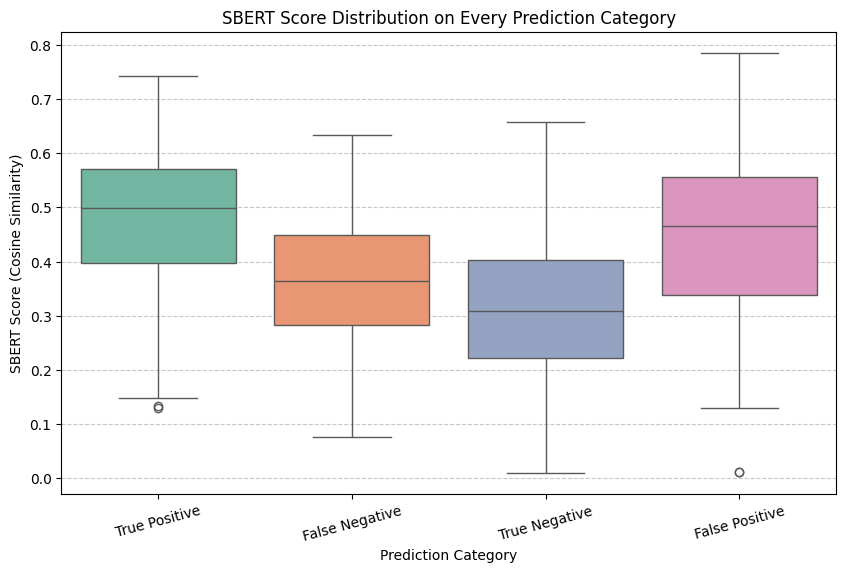

In [6]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_viz, x='category', y='RELEVANCE_FEAT', palette='Set2')

plt.title("SBERT Score Distribution on Every Prediction Category")
plt.ylabel("SBERT Score (Cosine Similarity)")
plt.xlabel("Prediction Category")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Biar label x gak numpuk
plt.xticks(rotation=15)
plt.show()

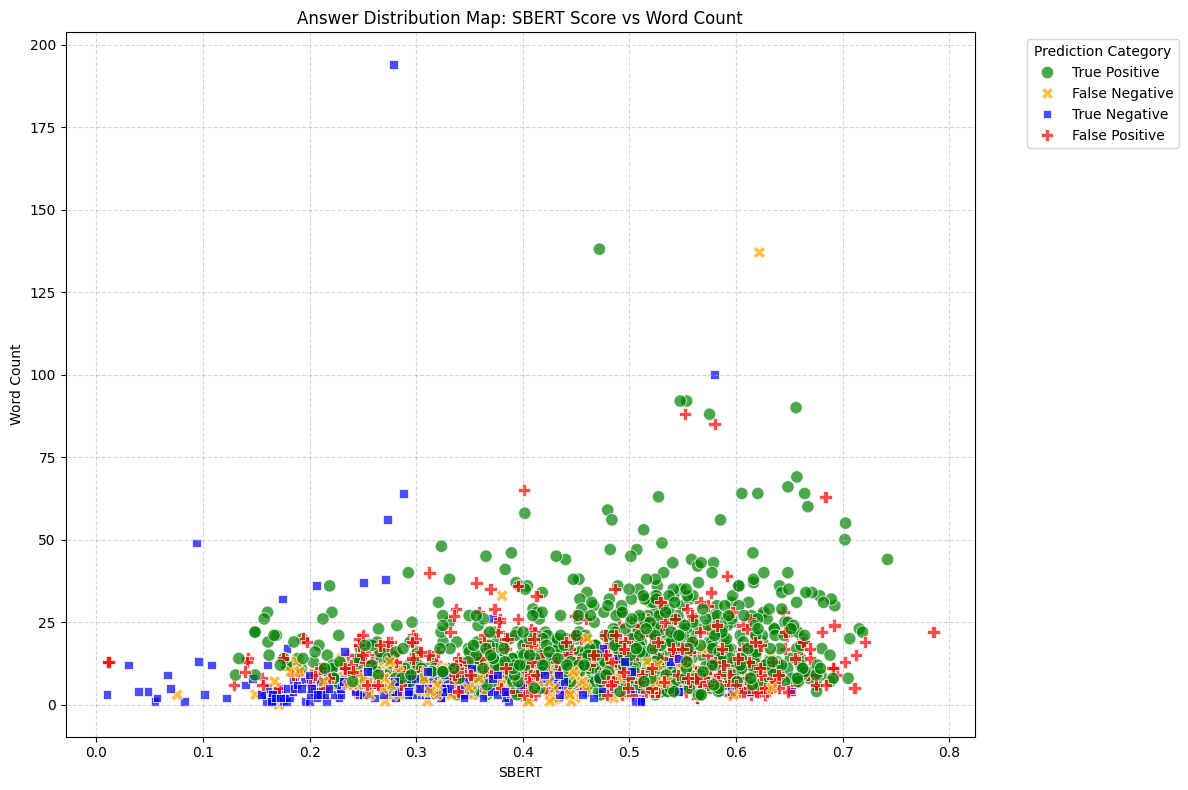

In [7]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
   data=df_viz,
   x='RELEVANCE_FEAT',
   y='total_words',
   hue='category',
   style='category',
   s=80,
   alpha=0.7,
   palette={
      "True Positive": "green",
      "True Negative": "blue",
      "False Positive": "red",
      "False Negative": "orange"
   }
)

plt.title("Answer Distribution Map: SBERT Score vs Word Count")
plt.xlabel("SBERT")
plt.ylabel("Word Count")
plt.legend(title="Prediction Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

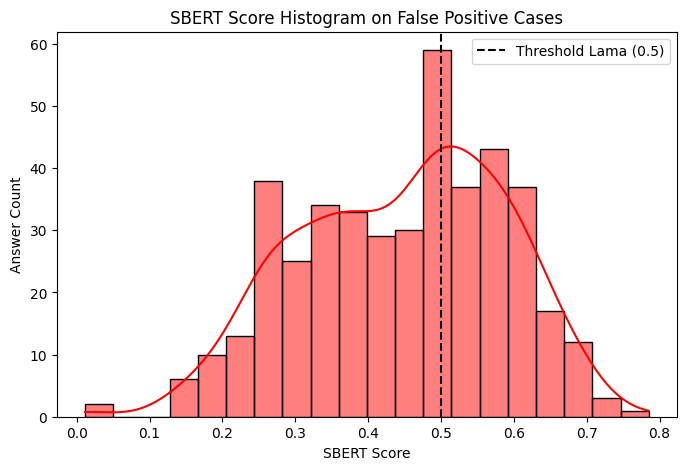

In [8]:
# Filter cuma data False Positive
fp_data = df_viz[df_viz['category'] == 'False Positive']

plt.figure(figsize=(8, 5))
sns.histplot(fp_data['RELEVANCE_FEAT'], bins=20, kde=True, color='red')

plt.title("SBERT Score Histogram on False Positive Cases")
plt.xlabel("SBERT Score")
plt.ylabel("Answer Count")
plt.axvline(0.5, color='black', linestyle='--', label='Threshold Lama (0.5)') # Garis batas
plt.legend()
plt.show()

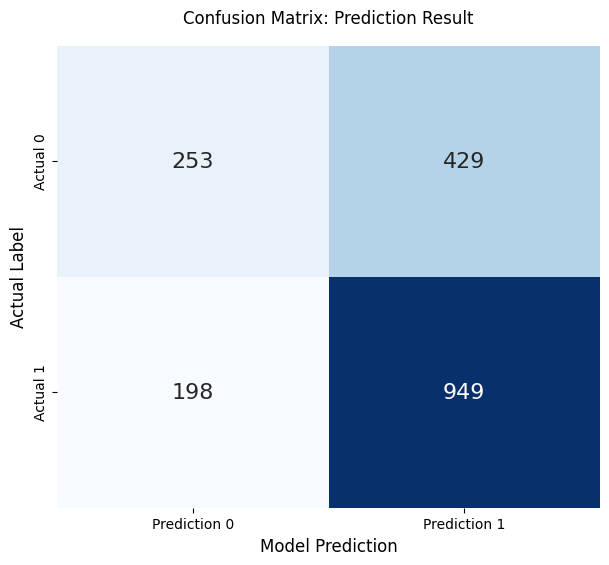

In [9]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_class_test)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 16}, # Ukuran font angka
            xticklabels=['Prediction 0', 'Prediction 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.xlabel('Model Prediction', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Confusion Matrix: Prediction Result', fontsize=12, pad=16)
plt.show()

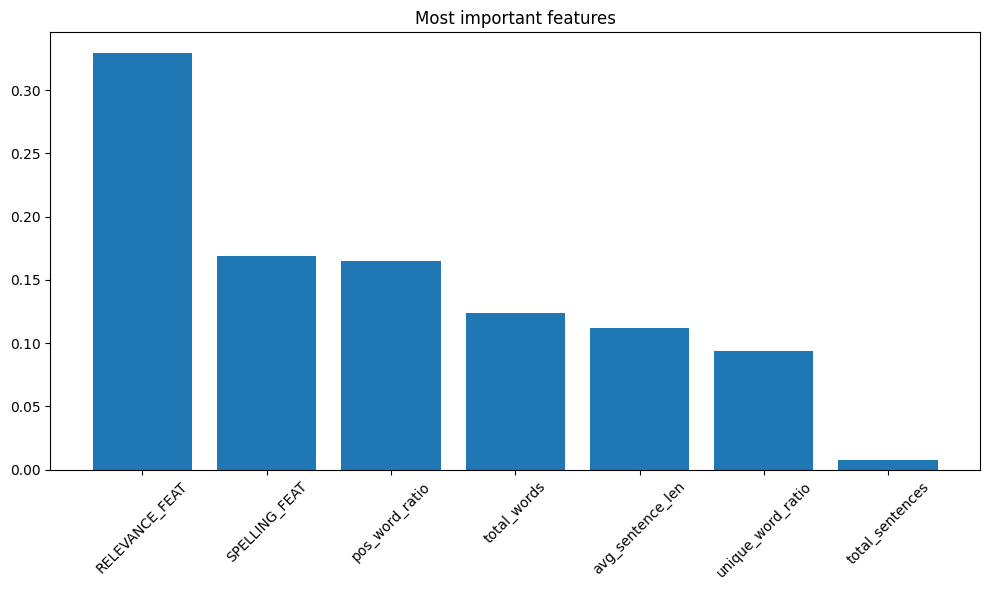

In [10]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

df_train = pd.read_csv("{}/df_train_final.csv".format(DIR_DATA))
X_train = df_train[feature_cols].values
y_train = df_train['LABEL'].values

rf_train = RandomForestClassifier(n_estimators=100, random_state=42)
rf_train.fit(X_train, y_train)

importances_test = rf_train.feature_importances_
indices_test = np.argsort(importances_test)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Most important features")
plt.bar(range(len(feature_cols)), importances_test[indices_test], align="center")
plt.xticks(range(len(feature_cols)), [feature_cols[i] for i in indices_test], rotation=45)
plt.tight_layout()
plt.show()